# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.dgp import DataGenerationProcess, MNLAssortment
from core.variables import *
from core.structural import * 

# DGP

In [135]:
dgp_params = {
    'prod_fe_vars': [PointMass(1 + i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

dgp = MNLAssortment(**dgp_params)

In [136]:
purchase_records = dgp.sample(100, seed=0)

# Estimation

In [11]:
emp_effects_arr = estimate_fixed_effects(purchase_records, dgp.n_products)

# Optimization

In [8]:
assortment, val_est = optimize(emp_effects_arr, int(dgp.n_products / 2))

# Evaluation

In [9]:
val_est = obj_func(emp_effects_arr, assortment)
val_true = obj_func(dgp.prod_fixed_effects, assortment)

result_df = pd.DataFrame({
    'Top-k Assortment': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Top-k Assortment
Estimated Policy Value,0.949739
True Policy Value,0.948980
Winner's Curse,0.000759


In [10]:
del val_est, val_true, result_df, assortment, emp_effects_arr, purchase_records, dgp

# Winner's Curse

In [111]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

In [112]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True,
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.7s finished


In [113]:
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_avg = wc_measures_dict[f'{optimizer}_nc_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer}_nc_wc_se']

    val_true_avg = wc_measures_dict[f'{optimizer}_nc_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer}_nc_val_true_se']
    val_est_avg = wc_measures_dict[f'{optimizer}_nc_val_est_avg']
    val_est_se = wc_measures_dict[f'{optimizer}_nc_val_est_se']

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Top 50%:
  - Average True Value: 0.8331 (0.0001)
  - Average Estimated Value: 0.8619 (0.0041)
  - Average Winner's Curse (%): 288.41% (40.81%)


# Estimating Winner's Curse

In [114]:
dgp = MNLAssortment(**dgp_params)
purchase_records = dgp.sample(100, seed=13)

In [115]:
emp_effects_arr = estimate_fixed_effects(purchase_records, dgp.n_products)

## Standard Bootstrap

In [116]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    n_bootstraps=500, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished


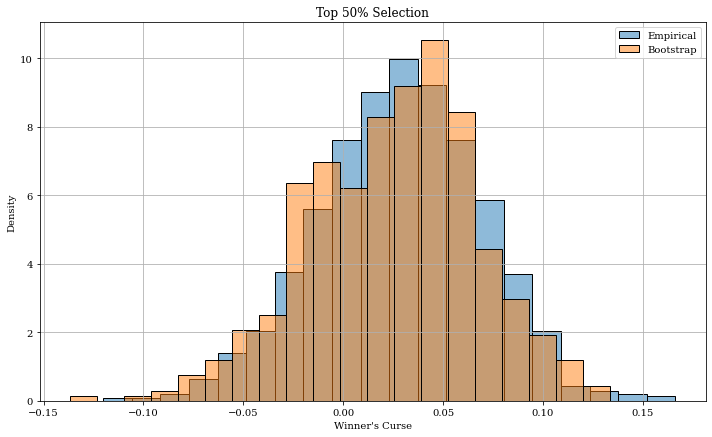

In [117]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [118]:
boot_wc_dstn_dict = get_wc_m_out_of_n_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    n_bootstraps=500, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished


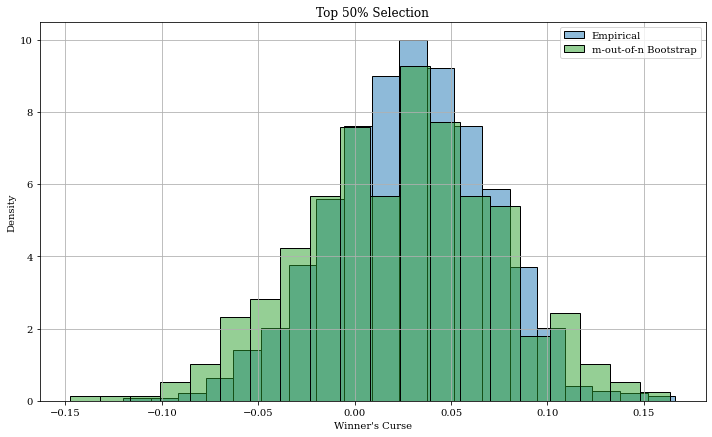

In [119]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [120]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    power=-0.45, 
    n_bootstraps=500, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished


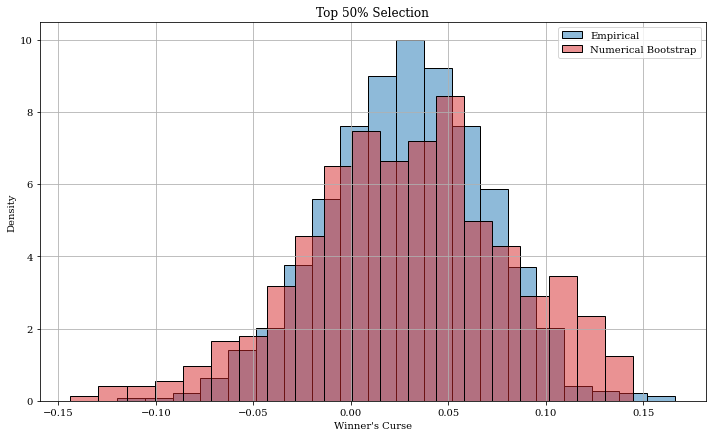

In [121]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [122]:
del dgp, purchase_records, emp_effects_arr, boot_wc_dstn_dict

# Bias Correction

In [5]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.05) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayesian': {
        'estimator': bayesian_mnl_estimate,
        'params': {'n_draws': 1000, 'n_warmup': 500},
        'display_name': 'Bayesian',
    }, 
}

In [6]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True,
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   52.4s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.3min finished


In [7]:
with open('results/mnl_assort_bias_correction.pkl', 'wb') as f:
    pickle.dump(wc_measures_dict, f)

with open('results/mnl_assort_bias_correction.pkl', 'rb') as f:
    wc_measures_dict = pickle.load(f)


Selection with Top 50%:
Policy Value: 
  - True Value: 0.8632 (0.0005)
  - No Correction: 0.8858 (0.0037)
  - Standard Bootstrap: 0.8724 (0.0041)
  - m-out-of-n Bootstrap: 0.8702 (0.0042)
  - Numerical Bootstrap: 0.8708 (0.0042)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 45.23% (7.38%)
  - Standard Bootstrap: 18.47% (8.26%)
  - m-out-of-n Bootstrap: 14.16% (8.37%)
  - Numerical Bootstrap: 15.23% (8.50%)
Median Winner's Curse: 
  - No Correction: 47.79% (7.38%)
  - Standard Bootstrap: 19.03% (8.26%)
  - m-out-of-n Bootstrap: 17.96% (8.37%)
  - Numerical Bootstrap: 16.86% (8.50%)

Sample Splitting: 
  - True Value: 0.8614 (0.0006)
  - Estimated Value: 0.8651 (0.0068)
  - Winner's Curse (%): 7.51% (13.52%)

Bayesian: 
  - True Value: 0.8628 (0.0005)
  - Estimated Value: 0.8858 (0.0036)
  - Winner's Curse (%): 45.92% (7.18%)


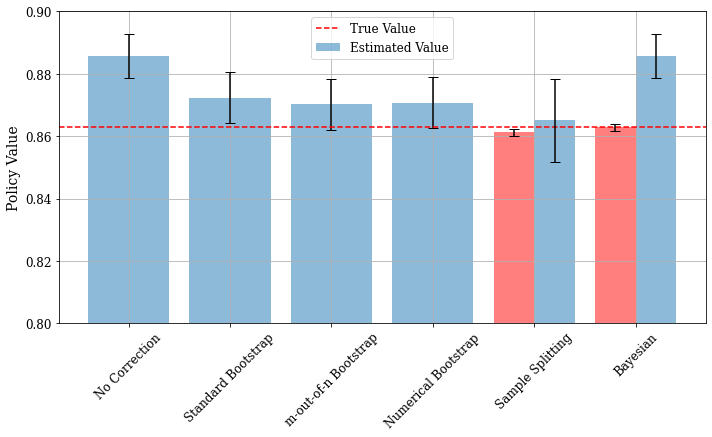

In [8]:
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

optimizer_key = 'top-0.5'
print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

own_policy_estimators = [key for key in estimators_dict.keys() if f'{optimizer_key}_{key}_val_true_avg' in wc_measures_dict.keys()]
focal_policy_estimators = [key for key in estimators_dict.keys() if key not in own_policy_estimators]

# true policy value of the focal policy
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + focal_policy_estimators:
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'
    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + focal_policy_estimators:
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'
    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + focal_policy_estimators:
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'
    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

for estimator in own_policy_estimators:
    display_name = estimators_dict[estimator]['display_name']
    print(f'\n{display_name}: ')
    val_true_avg = wc_measures_dict[f'{optimizer_key}_{estimator}_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer_key}_{estimator}_val_true_se']
    val_est_avg = wc_measures_dict[f'{optimizer_key}_{estimator}_val_est_avg']
    val_est_se = wc_measures_dict[f'{optimizer_key}_{estimator}_val_est_se']
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator}_wc_se']

    print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(1 + len(focal_policy_estimators))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + focal_policy_estimators
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + focal_policy_estimators
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
for idx, estimator_name in enumerate(own_policy_estimators):
    bar_width = 0.4
    ax.bar(
        bar_positions[-1] + idx + 1 - bar_width / 2, 
        wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_true_avg'], 
        yerr=1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_true_se'], 
        capsize=5, color='red', width=bar_width, alpha=0.5
    )
    ax.bar(
        bar_positions[-1] + idx + 1 + bar_width / 2,
        wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg'],
        yerr=1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se'],
        capsize=5, color='C0', width=bar_width, alpha=0.5
    )

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(1 + len(focal_policy_estimators) + len(own_policy_estimators)), 
    labels=['No Correction'] + [estimators_dict[k]['display_name'] for k in focal_policy_estimators] + [estimators_dict[k]['display_name'] for k in own_policy_estimators],
    rotation=45, 
    fontsize=tick_label_size
)

ax.set_ylim([0.8, 0.9])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Comparative Statics

## Delta tau

In [9]:
dgp_params = {
    'prod_fe_vars': [None] * 10, 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayesian': {
        'estimator': bayesian_mnl_estimate,
        'params': {'n_draws': 1000, 'n_warmup': 500},
        'display_name': 'Bayesian',
    }, 
}

### Base = -0.05

In [10]:
base_effect = -0.05
delta_tau_list = [0.01, 0.05, 0.1, 0.15, 0.2]

delta_tau_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta Tau: {delta_tau}')

    dgp_params['prod_fe_vars'] = [PointMass(delta_tau * i) for i in range(10)]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    delta_tau_result_dict[delta_tau] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta Tau: 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    7.3s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   48.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   47.2s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   54.1s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.15
Running 500 experiments...


/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    9.7s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Para


Delta Tau: 0.2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   10.7s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/User

In [ ]:
with open('results/mnl_assort_delta_tau.pkl', 'wb') as f:
    pickle.dump(delta_tau_result_dict, f)

with open('results/mnl_assort_delta_tau.pkl', 'rb') as f:
    delta_tau_result_dict = pickle.load(f)

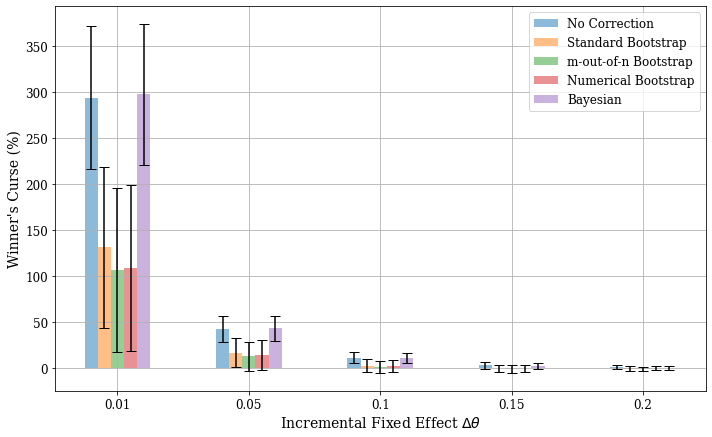

$\Delta\tau=0.01$  $\Delta\tau=0.05$  \
No Correction        Mean               294.14              42.96   
                     Median             307.78              43.40   
                     S.E.                39.57               7.18   
Standard Bootstrap   Mean               131.40              17.09   
                     Median             148.26              19.19   
                     S.E.                44.79               8.07   
m-out-of-n Bootstrap Mean               106.68              13.05   
                     Median             106.18              16.20   
                     S.E.                45.33               8.18   
Numerical Bootstrap  Mean               108.58              14.27   
                     Median             128.31              15.43   
                     S.E.                45.94               8.31   
Bayesian             Mean               297.64              43.56   
                     Median             319.92              45.79   
                     S.E.                39.00               7.04   

                             $\Delta\tau=0.1$  $\Delta\tau=0.15$  \
No Correction        Mean               11.45               3.32   
                     Median             13.99               5.24   
                     S.E.                3.06               1.78   
Standard Bootstrap   Mean                3.04               0.02   
                     Median              4.62               1.10   
                     S.E.                3.38               1.94   
m-out-of-n Bootstrap Mean                1.39              -0.65   
                     Median              2.49               0.68   
                     S.E.                3.45               1.98   
Numerical Bootstrap  Mean                2.64               0.27   
                     Median              4.99               1.75   
                     S.E.                3.48               2.00   
Bayesian             Mean               11.36               2.85   
                     Median             13.73               4.35   
                     S.E.                2.98               1.73   

                             $\Delta\tau=0.2$  
No Correction        Mean                1.07  
                     Median              2.63  
                     S.E.                1.12  
Standard Bootstrap   Mean               -0.29  
                     Median              0.83  
                     S.E.                1.20  
m-out-of-n Bootstrap Mean               -0.58  
                     Median              0.68  
                     S.E.                1.21  
Numerical Bootstrap  Mean                0.18  
                     Median              1.70  
                     S.E.                1.23  
Bayesian             Mean                0.57  
                     Median              1.95  
                     S.E.                1.08

In [27]:
# parameters
optimizer_key = 'top-0.5'
result_dict = delta_tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Incremental Fixed Effect $\Delta\theta$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [29]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{lllllll}
 &  & $\Delta\tau=0.01$ & $\Delta\tau=0.05$ & $\Delta\tau=0.1$ & $\Delta\tau=0.15$ & $\Delta\tau=0.2$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 294.14\% & 42.96\% & 11.45\% & 3.32\% & 1.07\% \\
 & Median & 307.78\% & 43.40\% & 13.99\% & 5.24\% & 2.63\% \\
 & S.E. & 39.57\% & 7.18\% & 3.06\% & 1.78\% & 1.12\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 131.40\% & 17.09\% & 3.04\% & 0.02\% & -0.29\% \\
 & Median & 148.26\% & 19.19\% & 4.62\% & 1.10\% & 0.83\% \\
 & S.E. & 44.79\% & 8.07\% & 3.38\% & 1.94\% & 1.20\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 106.68\% & 13.05\% & 1.39\% & -0.65\% & -0.58\% \\
 & Median & 106.18\% & 16.20\% & 2.49\% & 0.68\% & 0.68\% \\
 & S.E. & 45.33\% & 8.18\% & 3.45\% & 1.98\% & 1.21\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & 108.58\% & 14.27\% & 2.64\% & 0.27\% & 0.18\% \\
 & Median & 128.31\% & 15.43\% & 4.99\% & 1.75\% & 1.70\% \\
 & S.E. & 45.94\% & 8.31\% & 3.48\% & 2.00\% & 1.23\% \\
\multir

### Base = -0.1

In [30]:
base_effect = -0.1
delta_tau_list = [0.01, 0.05, 0.1, 0.15, 0.2]

delta_tau_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta Tau: {delta_tau}')

    dgp_params['prod_fe_vars'] = [PointMass(delta_tau * i) for i in range(10)]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    delta_tau_result_dict[delta_tau] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta Tau: 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   55.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   54.8s
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   57.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.15
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   57.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   58.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.7min finished


In [31]:
with open('results/mnl_assort_delta_tau_1e-1.pkl', 'wb') as f:
    pickle.dump(delta_tau_result_dict, f)

with open('results/mnl_assort_delta_tau_1e-1.pkl', 'rb') as f:
    delta_tau_result_dict = pickle.load(f)

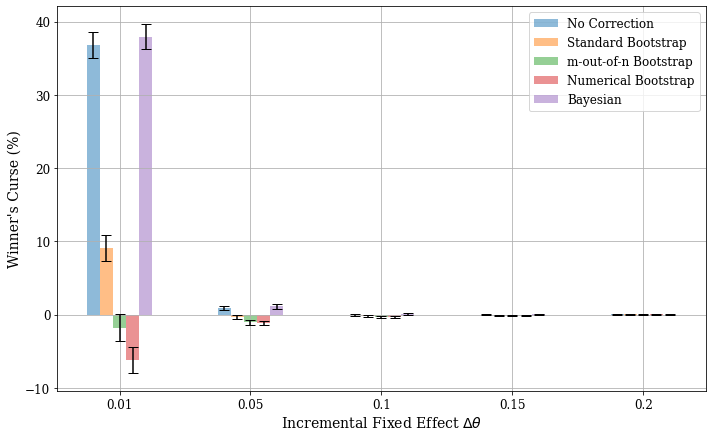

$\Delta\tau=0.01$  $\Delta\tau=0.05$  \
No Correction        Mean                36.82               0.92   
                     Median              36.85               1.63   
                     S.E.                 0.89               0.16   
Standard Bootstrap   Mean                 9.11              -0.31   
                     Median               9.77               0.29   
                     S.E.                 0.91               0.17   
m-out-of-n Bootstrap Mean                -1.76              -1.06   
                     Median               0.23              -0.47   
                     S.E.                 0.92               0.17   
Numerical Bootstrap  Mean                -6.18              -1.12   
                     Median              -5.49              -0.93   
                     S.E.                 0.93               0.17   
Bayesian             Mean                37.96               1.14   
                     Median              37.35               1.76   
                     S.E.                 0.89               0.16   

                             $\Delta\tau=0.1$  $\Delta\tau=0.15$  \
No Correction        Mean               -0.03              -0.03   
                     Median              0.08              -0.21   
                     S.E.                0.07               0.04   
Standard Bootstrap   Mean               -0.17              -0.05   
                     Median              0.00              -0.20   
                     S.E.                0.07               0.04   
m-out-of-n Bootstrap Mean               -0.27              -0.07   
                     Median             -0.25              -0.28   
                     S.E.                0.07               0.04   
Numerical Bootstrap  Mean               -0.25              -0.05   
                     Median             -0.16              -0.10   
                     S.E.                0.07               0.04   
Bayesian             Mean                0.11               0.05   
                     Median              0.25              -0.13   
                     S.E.                0.07               0.04   

                             $\Delta\tau=0.2$  
No Correction        Mean                0.03  
                     Median              0.03  
                     S.E.                0.02  
Standard Bootstrap   Mean                0.04  
                     Median              0.03  
                     S.E.                0.02  
m-out-of-n Bootstrap Mean                0.03  
                     Median              0.03  
                     S.E.                0.02  
Numerical Bootstrap  Mean                0.05  
                     Median              0.02  
                     S.E.                0.02  
Bayesian             Mean                0.02  
                     Median              0.03  
                     S.E.                0.02

In [32]:
# parameters
optimizer_key = 'top-0.5'
result_dict = delta_tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Incremental Fixed Effect $\Delta\theta$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Capacity

In [13]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.05) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': None}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayesian': {
        'estimator': bayesian_mnl_estimate,
        'params': {'n_draws': 1000, 'n_warmup': 500},
        'display_name': 'Bayesian',
    }, 
}

In [14]:
capacity_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]

capacity_result_dict = {capacity: None for capacity in capacity_list}

for capacity in capacity_list:
    print(f'\nCapacity: {capacity}')

    optimization_params['top-0.5']['params']['capacity'] = capacity

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    capacity_result_dict[capacity] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Capacity: 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   48.6s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.0min
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 3
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.2min
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.1min
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 9
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.2min
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.1min finished


In [ ]:
with open('results/mnl_assort_capacity.pkl', 'wb') as f:
    pickle.dump(capacity_result_dict, f)

with open('results/mnl_assort_capacity.pkl', 'rb') as f:
    capacity_result_dict = pickle.load(f)

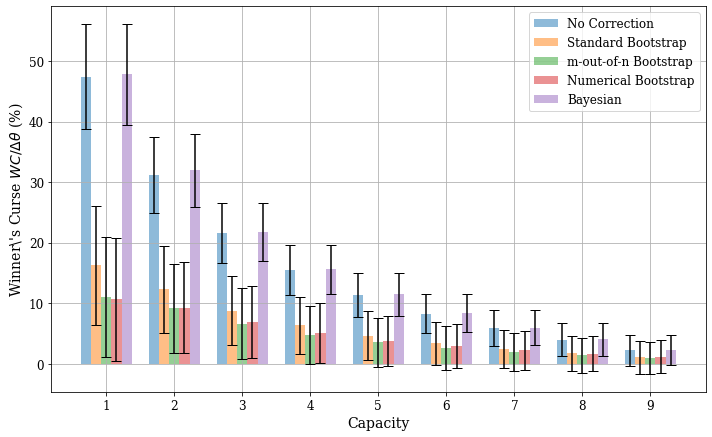

Capacity=1  Capacity=2  Capacity=3  Capacity=4  \
No Correction        Mean         47.45       31.23       21.61       15.48   
                     Median       46.40       30.93       22.13       15.89   
                     S.E.          4.43        3.20        2.53        2.12   
Standard Bootstrap   Mean         16.27       12.30        8.79        6.32   
                     Median       13.49       12.43        9.14        6.28   
                     S.E.          5.00        3.69        2.90        2.41   
m-out-of-n Bootstrap Mean         11.00        9.13        6.65        4.80   
                     Median        8.77        9.95        7.48        6.41   
                     S.E.          5.08        3.76        2.96        2.45   
Numerical Bootstrap  Mean         10.65        9.29        6.90        5.08   
                     Median        7.94        9.06        7.75        6.05   
                     S.E.          5.19        3.84        3.00        2.49   
Bayesian             Mean         47.78       31.97       21.76       15.63   
                     Median       45.89       32.29       22.45       16.46   
                     S.E.          4.24        3.08        2.45        2.06   

                             Capacity=5  Capacity=6  Capacity=7  Capacity=8  \
No Correction        Mean         11.31        8.25        5.93        3.97   
                     Median       11.95        8.75        7.44        5.47   
                     S.E.          1.84        1.64        1.50        1.39   
Standard Bootstrap   Mean          4.62        3.38        2.48        1.72   
                     Median        4.76        4.15        3.17        2.66   
                     S.E.          2.07        1.81        1.62        1.47   
m-out-of-n Bootstrap Mean          3.54        2.61        1.95        1.41   
                     Median        4.49        3.53        2.91        2.44   
                     S.E.          2.09        1.83        1.63        1.48   
Numerical Bootstrap  Mean          3.81        2.89        2.23        1.67   
                     Median        4.22        3.45        2.60        2.35   
                     S.E.          2.13        1.85        1.65        1.50   
Bayesian             Mean         11.48        8.36        5.95        4.05   
                     Median       12.34        9.45        7.34        5.65   
                     S.E.          1.80        1.61        1.47        1.37   

                             Capacity=9  
No Correction        Mean          2.23  
                     Median        4.31  
                     S.E.          1.31  
Standard Bootstrap   Mean          1.06  
                     Median        1.94  
                     S.E.          1.36  
m-out-of-n Bootstrap Mean          0.93  
                     Median        2.15  
                     S.E.          1.36  
Numerical Bootstrap  Mean          1.18  
                     Median        1.97  
                     S.E.          1.38  
Bayesian             Mean          2.26  
                     Median        4.27  
                     S.E.          1.29

In [38]:
# parameters
optimizer_key = 'top-0.5'
result_dict = capacity_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for capacity in capacity_list:
    data[capacity] = {}

    data[capacity]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[capacity][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[capacity][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[capacity][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for capacity in capacity_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[capacity][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=['Capacity={}'.format(p) for p in capacity_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(capacity_list))
bar_width = 0.15 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in capacity_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in capacity_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Capacity', fontsize=axis_label_size)
ax.set_ylabel(r'Winner\'s Curse $WC / \Delta\theta$ (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(capacity_list)), labels=capacity_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Sample Size

In [17]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.05) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': None}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayesian': {
        'estimator': bayesian_mnl_estimate,
        'params': {'n_draws': 1000, 'n_warmup': 500},
        'display_name': 'Bayesian',
    }, 
}

In [18]:
sample_size_list = [100, 500, 1000, 2500, 5000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size: {sample_size}')

    data_params['sample_size'] = sample_size

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size: 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.1min
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:60: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 1000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   58.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.3min finished


In [19]:
with open('results/mnl_assort_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

with open('results/mnl_assort_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

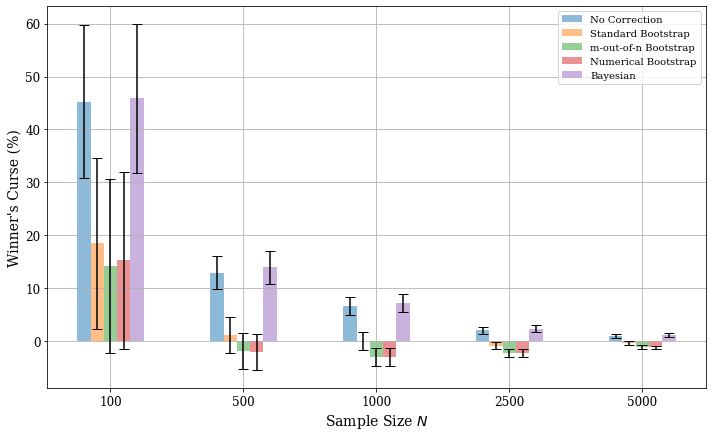

$N=100$  $N=500$  $N=1000$  $N=2500$  $N=5000$
No Correction        Mean      45.23    12.92      6.56      2.01      0.91
                     Median    47.79    11.34      5.48      2.20      0.87
                     S.E.       7.38     1.63      0.85      0.35      0.17
Standard Bootstrap   Mean      18.47     1.08     -0.06     -0.90     -0.38
                     Median    19.03    -0.69     -0.85     -0.56     -0.32
                     S.E.       8.26     1.72      0.87      0.35      0.17
m-out-of-n Bootstrap Mean      14.16    -1.94     -3.03     -2.31     -1.16
                     Median    17.96    -3.37     -4.01     -2.06     -1.14
                     S.E.       8.37     1.74      0.88      0.36      0.17
Numerical Bootstrap  Mean      15.23    -2.14     -3.00     -2.24     -1.22
                     Median    16.86    -4.01     -4.35     -2.21     -1.25
                     S.E.       8.50     1.76      0.90      0.36      0.17
Bayesian             Mean      45.92    13.93      7.13      2.31      1.12
                     Median    49.38    12.55      5.66      2.34      0.99
                     S.E.       7.18     1.62      0.85      0.35      0.17

In [20]:
# parameters
optimizer_key = 'top-0.5'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)